# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../../data/test.pickle")


In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import random
import pickle


In [2]:
import torch, numpy as np, random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


C:\Users\anuhe\AppData\Local\Temp\ipykernel_17876\795435323.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_17876\795435323.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct

           velocity          mass  deceleration_average
count  4.053000e+03  4.053000e+03          4.053000e+03
mean  -1.039605e-15 -5.049008e-16         -3.155630e-16
std    1.000123e+00  1.000123e+00          1.000123e+00
min   -1.344505e+01 -7.759426e-01         -3.487379e+00
25%   -4.975778e-04 -7.759426e-01         -6.693355e-01
50%   -4.975778e-04 -7.759426e-01          1.530402e-02
75%   -4.975778e-04  1.391196e+00          6.317576e-01
max    2.688413e+00  1.391196e+00          8.531451e+00


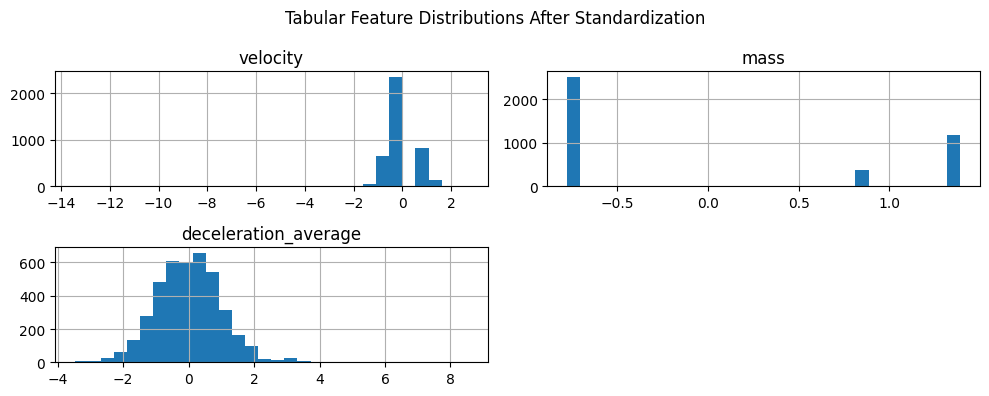

In [ ]:
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# def load_pickle(path):
#     with open(path, 'rb') as f:
#         return pickle.load(f)
#
# # Load and prepare data
# train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
# test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")

train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

# Separate sensor and tabular data
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

# Combine tabular data for KNN imputation
X_combined = pd.concat([X_train_tab, X_test_tab], ignore_index=True)

# Perform KNN imputation on the combined tabular data
imputer = KNNImputer(n_neighbors=5)
X_combined_imputed = imputer.fit_transform(X_combined)

# Split back the imputed data into train and test
X_train_tab_imputed = X_combined_imputed[:len(X_train_tab)]
X_test_tab_imputed = X_combined_imputed[len(X_train_tab):]

# Standardize the tabular data
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab_imputed)
X_test_tab_scaled = scaler.transform(X_test_tab_imputed)

# Optionally visualize
tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
print(tab_df.describe())
tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()

# Sensor preprocessing
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

sensor_scaler = RobustScaler()
flat_train_scaled = sensor_scaler.fit_transform(flat_train)
flat_test_scaled = sensor_scaler.transform(flat_test)

X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)


In [4]:
import numpy as np
import pandas as pd

# Combine all data for easier filtering
X_train_tab = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
X_train_sensor = np.array(X_train_sensor_clipped)
y_train = np.array(y_train)

# Get indices for each class
indices_class_0 = np.where(y_train == 0)[0]
indices_other = np.where(y_train != 0)[0]

# Randomly sample 500 from class 0
np.random.seed(42)  # for reproducibility
selected_class_0 = np.random.choice(indices_class_0, 500, replace=False)

# Combine with other classes
final_indices = np.concatenate([selected_class_0, indices_other])

# Shuffle indices
np.random.shuffle(final_indices)

# Undersampled datasets
X_train_tab_undersampled = X_train_tab.iloc[final_indices].reset_index(drop=True)
X_train_sensor_undersampled = X_train_sensor[final_indices]
y_train_undersampled = y_train[final_indices]


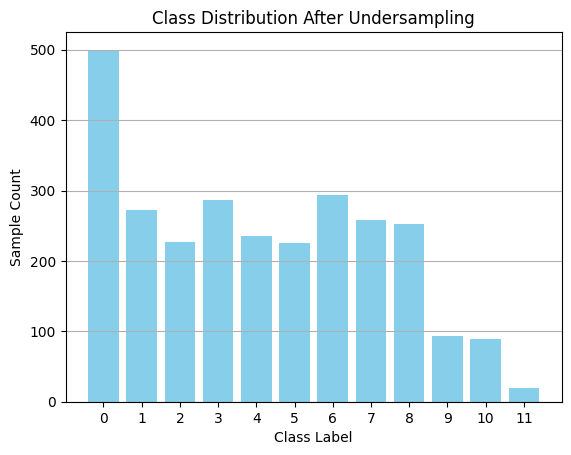

Tabular shape: (2755, 3)
Sensor shape: (2755, 128, 6)
Labels shape: (2755,)


In [5]:
import matplotlib.pyplot as plt

plt.hist(y_train_undersampled, bins=np.arange(y_train.max() + 2) - 0.5, rwidth=0.8, color='skyblue')
plt.xlabel("Class Label")
plt.ylabel("Sample Count")
plt.title("Class Distribution After Undersampling")
plt.xticks(np.arange(y_train.max() + 1))
plt.grid(axis='y')
plt.show()
print("Tabular shape:", X_train_tab_undersampled.shape)
print("Sensor shape:", X_train_sensor_undersampled.shape)
print("Labels shape:", y_train_undersampled.shape)


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Create a small, clear figure for subplots
plt.figure(figsize=(3.5, 2.5))  # suitable size for 4x4 grid on A4

# Histogram for augmented data
unique_aug, counts_aug = np.unique(y_train_undersampled, return_counts=True)
plt.bar(unique_aug, counts_aug, color='skyblue')

plt.xlabel("Class", fontsize=8)
plt.ylabel("Count", fontsize=8)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()

# Save figure for LaTeX subfigure use
plt.savefig("C:/Study and work/Sem 6/Neural Networks, Deep Learning and Applications/Report/class_dist_after_undersampling.png", dpi=300)
plt.close()


# Model architecture


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
import random
import pandas as pd

# --- Dataset ---
class SensorDataset(Dataset):
    def __init__(self, sensor_seqs, tabular_feats, labels):
        self.sensor_seqs = torch.tensor(sensor_seqs, dtype=torch.float32)
        if isinstance(tabular_feats, pd.DataFrame):
            tabular_feats = tabular_feats.values
        self.tabular_feats = torch.tensor(tabular_feats, dtype=torch.float32)
        if isinstance(labels, pd.Series):
            labels = labels.values
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_seqs[idx], self.tabular_feats[idx], self.labels[idx]

# --- Model ---
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_layers=2, tabular_dim=3,
                 tab_hidden_dim=32, output_dim=12, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)
        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim + tab_hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_seq, x_tab):
        lstm_out, _ = self.lstm(x_seq)
        lstm_last = lstm_out[:, -1, :]
        tab_out = self.tabular_net(x_tab)
        combined = torch.cat((lstm_last, tab_out), dim=1)
        return self.classifier(combined)

# --- Training & Evaluation ---
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_seq, x_tab, y in dataloader:
        x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x_seq, x_tab)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_f1(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return f1_score(all_labels, all_preds, average='weighted')

# --- Random Search with Early Stopping ---
param_space = {
    'hidden_dim': [32, 64, 128],
    'num_layers': [1, 2],
    'bidirectional': [True, False],
    'dropout': [0.1, 0.3, 0.5],
    'tab_hidden_dim': [16, 32, 64],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128]
}

def sample_hyperparams(param_space):
    return {k: random.choice(v) for k, v in param_space.items()}

def run_random_search_cv(sensor_data, tab_data, labels, num_trials=10, num_epochs=10, device='cuda', patience=3):
    best_f1 = -1
    best_params = None
    best_model_state = None

    for trial in range(num_trials):
        print(f"\nTrial {trial+1}/{num_trials}")
        params = sample_hyperparams(param_space)
        print("Params:", params)

        all_f1_scores = []
        for split in range(10):
            X_tr, X_val, T_tr, T_val, y_tr, y_val = train_test_split(
                sensor_data, tab_data, labels,
                test_size=0.2, stratify=labels, random_state=split + trial * 100
            )

            train_ds = SensorDataset(X_tr, T_tr, y_tr)
            val_ds = SensorDataset(X_val, T_val, y_val)

            train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)

            model = LSTMClassifier(
                input_dim=sensor_data.shape[2],
                hidden_dim=params['hidden_dim'],
                num_layers=params['num_layers'],
                tabular_dim=tab_data.shape[1],
                tab_hidden_dim=params['tab_hidden_dim'],
                output_dim=len(np.unique(labels)),
                dropout=params['dropout'],
                bidirectional=params['bidirectional']
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
            criterion = nn.CrossEntropyLoss()

            best_val_f1 = -1
            epochs_no_improve = 0
            best_model_weights = None

            for epoch in range(num_epochs):
                train_one_epoch(model, train_loader, optimizer, criterion, device)
                val_f1 = evaluate_f1(model, val_loader, device)

                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    epochs_no_improve = 0
                    best_model_weights = model.state_dict()
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    print(f"Early stopping at epoch {epoch+1} (best val F1: {best_val_f1:.4f})")
                    break

            model.load_state_dict(best_model_weights)
            all_f1_scores.append(best_val_f1)

        avg_f1 = np.mean(all_f1_scores)
        print(f"Average F1 score: {avg_f1:.4f}")

        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_params = params
            best_model_state = model.state_dict()
            torch.save(best_model_state, "Undersampled_LSTM_BEST_MODEL.pth")

    print("\nBest Hyperparameters Found:")
    print(best_params)
    print(f"Best Average F1: {best_f1:.4f}")
    return best_params, best_f1, best_model_state


# train data

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

best_params, best_f1, best_model_state = run_random_search_cv(
    sensor_data=X_train_sensor_undersampled,
    tab_data=X_train_tab_undersampled,
    labels=y_train_undersampled,
    num_trials=10,
    num_epochs=15,
    device=device,
    patience=3
)



Trial 1/10
Params: {'hidden_dim': 32, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.1, 'tab_hidden_dim': 32, 'learning_rate': 0.0005, 'batch_size': 128}
Average F1 score: 0.7879

Trial 2/10
Params: {'hidden_dim': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.5, 'tab_hidden_dim': 16, 'learning_rate': 0.0005, 'batch_size': 32}
Early stopping at epoch 14 (best val F1: 0.9586)
Early stopping at epoch 14 (best val F1: 0.9781)
Average F1 score: 0.9756

Trial 3/10
Params: {'hidden_dim': 128, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.5, 'tab_hidden_dim': 16, 'learning_rate': 0.001, 'batch_size': 32}
Early stopping at epoch 13 (best val F1: 0.9818)
Early stopping at epoch 12 (best val F1: 0.9781)
Early stopping at epoch 13 (best val F1: 0.9854)
Early stopping at epoch 13 (best val F1: 0.9782)
Early stopping at epoch 14 (best val F1: 0.9837)
Average F1 score: 0.9826

Trial 4/10
Params: {'hidden_dim': 32, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.1, 't

# Load best model

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_params = {
    'hidden_dim': 64,
    'num_layers': 2,
    'bidirectional': True,
    'dropout': 0.1,
    'tab_hidden_dim': 64,
    'learning_rate': 0.001,
    'batch_size': 64
}
# Define model with best parameters
best_model = LSTMClassifier(
    input_dim=X_train_sensor_undersampled.shape[2],
    hidden_dim=best_params['hidden_dim'],
    num_layers=best_params['num_layers'],
    tabular_dim=X_train_tab_undersampled.shape[1],
    tab_hidden_dim=best_params['tab_hidden_dim'],
    output_dim=len(np.unique(y_train_undersampled)),
    dropout=best_params['dropout'],
    bidirectional=best_params['bidirectional']
).to(device)

# Load weights
best_model.load_state_dict(torch.load("Undersampled_LSTM_BEST_MODEL.pth"))
best_model.eval()


LSTMClassifier(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (tabular_net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)

In [11]:
test_dataset = SensorDataset(X_test_sensor_clipped, X_test_tab_scaled, y_test)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)


# Evaluate

In [12]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    acc = accuracy_score(all_labels, all_preds)
    return f1, acc

test_f1, test_acc = evaluate_model(best_model, test_loader, device)

print(f"\n Test F1 Score: {test_f1:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")



 Test F1 Score: 0.3259
 Test Accuracy: 0.2867


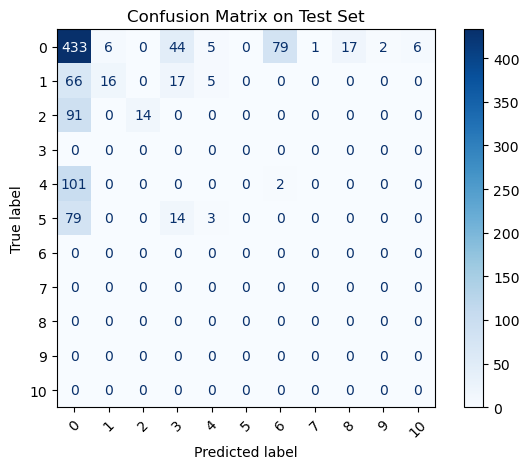

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Run model and collect predictions/labels
def get_preds_and_labels(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab = x_seq.to(device), x_tab.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    return all_preds, all_labels

preds, labels = get_preds_and_labels(best_model, test_loader, device)

# Compute and display confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()
